In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("../data/processed/cleaned_data.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [2]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

In [3]:
#creating RFM table
rfm = df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice" : "nunique",
    "TotalPrice": "sum"
})

In [4]:
#renaming columns
rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,524,10,327.86
12347.0,35,7,3598.29
12348.0,244,4,353.16
12349.0,14,3,2787.09
12350.0,305,1,294.40


In [5]:
#scales data from large numbers to (~ -1 to +1 range) same as in model notebook
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

In [6]:
#applying KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [7]:
rfm.groupby("Cluster").mean()

,Recency,Frequency,Monetary
Cluster,,,
0,65.248357,7.222344,1878.402377
1,451.304810,2.085063,456.822537
2,36.363636,176.909091,48918.046364


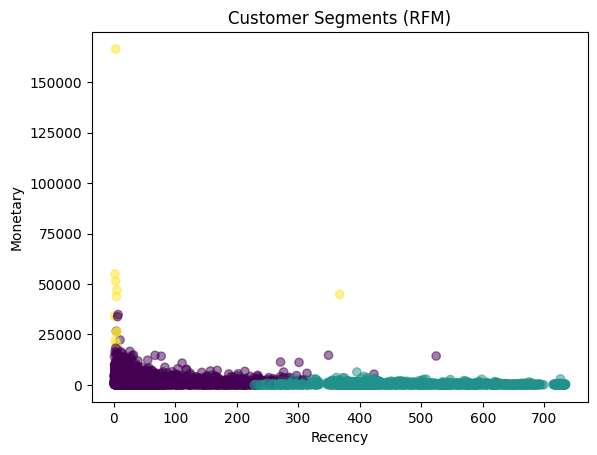

In [8]:
plt.scatter(rfm["Recency"], rfm["Monetary"], c=rfm["Cluster"], alpha=0.5)
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.title("Customer Segments (RFM)")
plt.show()

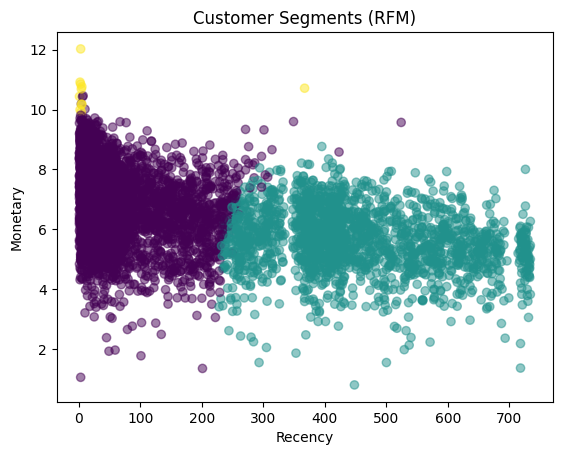

In [9]:
plt.scatter(rfm["Recency"], np.log1p(rfm["Monetary"]), c=rfm["Cluster"], alpha=0.5)
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.title("Customer Segments (RFM)")
plt.show()

In [10]:
rfm.to_csv("../data/processed/rfm_data.csv", index=True)